# RQ1 — Acoustic Feasibility

## Research question

> Does the movement that reaches the known true-gate digit contain a detectable acoustic difference from the other nine movements in the same scan?

RQ1 is a feasibility experiment. It asks whether the acoustic recording contains enough structure to place the true digit ahead of random ranking before introducing more complex questions about loading, motor noise, context or password generalisation.

### Data

- controlled `RQ1-4` dataset
- password: **3517**
- wheels: **W1, W2 and W4**
- direction: **CCW**
- **10 loaded scans per wheel**
- 10 one-digit movements per scan
- total: **30 scans / 300 movements**

### Hypotheses

- **H0:** the true-gate movement is not ranked better than random.
- **H1:** the true-gate movement shows repeatable acoustic structure that moves it toward the top of the 10-candidate ranking.

### Evidence used

The ranking result is the main feasibility evidence. The full true-rank distribution is shown rather than relying only on Top-1 accuracy.

Feature-level robust contrasts are then used to inspect what acoustic differences contribute to that ranking. These feature tests are secondary: with only 10 scans per wheel, failure of an individual feature to survive multiple-testing correction does not by itself invalidate a multivariate ranking effect.

RQ1 is deliberately limited to one password on one lock. It does not establish cross-password generalisation or prove that the useful signal originates from the lock rather than the drive system.

## 1. Load the controlled dataset and QC manifest

The raw archive is only extracted when it is needed. If the saved feature cache is already present, the expensive audio feature extraction step is skipped.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import zipfile
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
RAW_DRIVE = MYDRIVE / "dataset" / "raw"
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (p / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv").exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the RQ1-4 QC results folder under Padlock_Reproduction_v1."
    )

RESULT_DIR = RESULTS_ROOT / "01_RQ1_Acoustic_Feasibility"
CACHE_DIR = RESULTS_ROOT / "feature_cache"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

QC_MANIFEST = RESULTS_ROOT / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv"
CACHE_PATH = CACHE_DIR / "RQ1-4_interpretable_v1.npz"

zip_candidates = sorted(RAW_DRIVE.glob("RQ1-4*.zip"))
if not zip_candidates:
    raise FileNotFoundError(f"No RQ1-4 ZIP found in {RAW_DRIVE}")

DRIVE_ZIP = zip_candidates[0]
LOCAL_ZIP = Path("/content/RQ1-4.zip")
EXTRACT_ROOT = Path("/content/RQ1-4_extract")

manifest = pd.read_csv(QC_MANIFEST)

assert len(manifest) == 600
assert manifest["scan_id"].nunique() == 60
assert manifest["quality_valid"].all()
assert manifest["position_valid"].all()

dataset_summary = (
    manifest.groupby(["tension_state", "wheel"])
    .agg(
        scans=("scan_id", "nunique"),
        movements=("run_id", "size"),
        true_gate_movements=("is_true_gate", "sum"),
    )
    .reset_index()
)

dataset_summary.to_csv(
    RESULT_DIR / "RQ1_dataset_summary.csv",
    index=False,
)

print("Using raw ZIP :", DRIVE_ZIP.name)
print("QC manifest   :", QC_MANIFEST)
print("Feature cache :", CACHE_PATH)
print("Result folder :", RESULT_DIR)
display(dataset_summary)

Mounted at /content/drive
Using raw ZIP : RQ1-4.zip
QC manifest   : /content/drive/MyDrive/Padlock_Reproduction_v1/results/00_RQ1-4_QC/RQ1-4_qc_manifest.csv
Feature cache : /content/drive/MyDrive/Padlock_Reproduction_v1/results/feature_cache/RQ1-4_interpretable_v1.npz
Result folder : /content/drive/MyDrive/Padlock_Reproduction_v1/results/01_RQ1_Acoustic_Feasibility


,tension_state,wheel,scans,movements,true_gate_movements
0,LOADED,1,10,100,10
1,LOADED,2,10,100,10
2,LOADED,4,10,100,10
3,UNLOADED,1,10,100,10
4,UNLOADED,2,10,100,10
5,UNLOADED,4,10,100,10


## 2. Interpretable acoustic features

The same compact feature set used in the original RQ1 run is retained. Features are calculated only over the motion interval between `SCAN_START` and `SCAN_END`.

The target channel contributes 13 acoustic descriptors. The motor-reference channel and three cross-channel descriptors are also cached because the same cache is reused by RQ2–RQ4, although RQ1 itself uses only the target-channel features.

In [2]:
import soundfile as sf

EPS = 1e-12

BASE_FEATURES = [
    "rms",
    "peak",
    "crest",
    "derivative_rms",
    "zcr",
    "spectral_centroid_hz",
    "spectral_bandwidth_hz",
    "rolloff85_hz",
    "spectral_flatness",
    "spectral_entropy",
    "band_0_1k",
    "band_1_4k",
    "band_4_nyquist",
]

FEATURE_NAMES = (
    [f"target_{name}" for name in BASE_FEATURES]
    + [f"reference_{name}" for name in BASE_FEATURES]
    + [
        "cross_corr",
        "cross_log_rms_ratio",
        "cross_log_peak_ratio",
    ]
)


def signal_features(x, sr):
    x = np.asarray(x, dtype=np.float64)

    if len(x) < 16:
        raise ValueError("Signal window too short.")

    x = x - np.mean(x)

    rms = np.sqrt(np.mean(x ** 2))
    peak = np.max(np.abs(x))
    crest = peak / (rms + EPS)

    dx = np.diff(x)
    derivative_rms = np.sqrt(np.mean(dx ** 2))

    zcr = np.mean(
        np.signbit(x[:-1]) != np.signbit(x[1:])
    )

    window = np.hanning(len(x))
    power = np.abs(np.fft.rfft(x * window)) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / sr)

    total_power = np.sum(power) + EPS
    p = power / total_power

    centroid = np.sum(freqs * p)

    bandwidth = np.sqrt(
        np.sum(((freqs - centroid) ** 2) * p)
    )

    cumulative = np.cumsum(power)

    rolloff_idx = np.searchsorted(
        cumulative,
        0.85 * cumulative[-1]
    )
    rolloff_idx = min(rolloff_idx, len(freqs) - 1)
    rolloff85 = freqs[rolloff_idx]

    flatness = (
        np.exp(np.mean(np.log(power + EPS)))
        / (np.mean(power) + EPS)
    )

    spectral_entropy = (
        -np.sum(p * np.log(p + EPS))
        / np.log(len(p))
    )

    def band_ratio(low, high):
        mask = (freqs >= low) & (freqs < high)
        return np.sum(power[mask]) / total_power

    return np.array([
        rms,
        peak,
        crest,
        derivative_rms,
        zcr,
        centroid,
        bandwidth,
        rolloff85,
        flatness,
        spectral_entropy,
        band_ratio(0, 1000),
        band_ratio(1000, 4000),
        band_ratio(4000, sr / 2 + 1),
    ], dtype=np.float64)


def rms_envelope(x, bins=64):
    x = np.asarray(x, dtype=np.float64)
    chunks = np.array_split(x, bins)

    return np.array([
        np.sqrt(np.mean(chunk ** 2)) if len(chunk) else 0.0
        for chunk in chunks
    ])


def extract_run(run_dir):
    events = pd.read_csv(run_dir / "events.csv")

    start_rows = events[events["event"] == "SCAN_START"]
    end_rows = events[events["event"] == "SCAN_END"]

    if len(start_rows) != 1 or len(end_rows) != 1:
        raise ValueError(f"{run_dir.name}: invalid SCAN_START/SCAN_END")

    start = int(start_rows.iloc[0]["aligned_sample_index"])
    end = int(end_rows.iloc[0]["aligned_sample_index"]) + 1

    target, sr_target = sf.read(
        run_dir / "audio.wav",
        dtype="float32",
    )

    reference, sr_reference = sf.read(
        run_dir / "motor_reference.wav",
        dtype="float32",
    )

    if sr_target != 44100 or sr_reference != 44100:
        raise ValueError(f"{run_dir.name}: unexpected sample rate")

    if target.ndim != 1 or reference.ndim != 1:
        raise ValueError(f"{run_dir.name}: expected mono channel files")

    target = target[start:end]
    reference = reference[start:end]

    n = min(len(target), len(reference))
    target = target[:n]
    reference = reference[:n]

    target_features = signal_features(target, sr_target)
    reference_features = signal_features(reference, sr_reference)

    target_std = np.std(target)
    reference_std = np.std(reference)

    if target_std > EPS and reference_std > EPS:
        cross_corr = np.corrcoef(target, reference)[0, 1]
    else:
        cross_corr = 0.0

    cross_features = np.array([
        cross_corr,
        np.log(
            (target_features[0] + EPS)
            / (reference_features[0] + EPS)
        ),
        np.log(
            (target_features[1] + EPS)
            / (reference_features[1] + EPS)
        ),
    ])

    features = np.concatenate([
        target_features,
        reference_features,
        cross_features,
    ])

    return (
        features,
        rms_envelope(target, bins=64),
        rms_envelope(reference, bins=64),
        n,
    )


print("Cached feature count :", len(FEATURE_NAMES))
print("Target-channel RQ1   :", len(BASE_FEATURES))
print("Reference features   :", len(BASE_FEATURES))
print("Cross-channel        : 3")

Cached feature count : 29
Target-channel RQ1   : 13
Reference features   : 13
Cross-channel        : 3


## 3. Load or rebuild the shared RQ1–RQ4 feature cache

In [3]:
def find_runs(root):
    if not root.exists():
        return []

    return sorted(
        [
            p for p in root.rglob("run_*")
            if p.is_dir() and p.name.startswith("run_")
        ],
        key=lambda p: int(p.name.split("_")[-1]),
    )


if CACHE_PATH.exists():
    print("Loading existing cache:", CACHE_PATH)

    cache = np.load(CACHE_PATH, allow_pickle=False)

    X = cache["X"]
    env_target = cache["env_target"]
    env_reference = cache["env_reference"]
    cache_run_ids = cache["run_ids"]
    feature_names = cache["feature_names"]

else:
    run_dirs = find_runs(EXTRACT_ROOT)

    if len(run_dirs) != 600:
        print("Feature cache not found. Extracting the raw archive locally...")

        shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)

        if EXTRACT_ROOT.exists():
            shutil.rmtree(EXTRACT_ROOT)

        EXTRACT_ROOT.mkdir(parents=True)

        with zipfile.ZipFile(LOCAL_ZIP, "r") as z:
            z.extractall(EXTRACT_ROOT)

        run_dirs = find_runs(EXTRACT_ROOT)

    if len(run_dirs) != 600:
        raise RuntimeError(f"Expected 600 runs, found {len(run_dirs)}")

    run_map = {p.name: p for p in run_dirs}

    missing = [
        run_id
        for run_id in manifest["run_id"]
        if run_id not in run_map
    ]

    if missing:
        raise RuntimeError(f"{len(missing)} manifest runs are missing locally.")

    X_list = []
    env_target_list = []
    env_reference_list = []
    movement_samples = []
    run_ids = []

    for i, row in manifest.iterrows():
        run_id = row["run_id"]

        features, target_env, reference_env, n_samples = extract_run(
            run_map[run_id]
        )

        X_list.append(features)
        env_target_list.append(target_env)
        env_reference_list.append(reference_env)
        movement_samples.append(n_samples)
        run_ids.append(run_id)

        if (i + 1) % 100 == 0:
            print(f"{i + 1}/600 complete")

    X = np.vstack(X_list)
    env_target = np.vstack(env_target_list)
    env_reference = np.vstack(env_reference_list)

    cache_run_ids = np.asarray(run_ids, dtype="U16")
    feature_names = np.asarray(FEATURE_NAMES, dtype="U64")

    np.savez_compressed(
        CACHE_PATH,
        X=X,
        env_target=env_target,
        env_reference=env_reference,
        run_ids=cache_run_ids,
        feature_names=feature_names,
        movement_samples=np.asarray(movement_samples),
    )

    print("Cache saved:", CACHE_PATH)


assert X.shape == (600, 29)
assert env_target.shape == (600, 64)
assert env_reference.shape == (600, 64)
assert np.isfinite(X).all()
assert np.isfinite(env_target).all()
assert np.isfinite(env_reference).all()

print("X shape            :", X.shape)
print("Target envelopes   :", env_target.shape)
print("Reference envelopes:", env_reference.shape)
print("Cache QC           : PASS")

Loading existing cache: /content/drive/MyDrive/Padlock_Reproduction_v1/results/feature_cache/RQ1-4_interpretable_v1.npz
X shape            : (600, 29)
Target envelopes   : (600, 64)
Reference envelopes: (600, 64)
Cache QC           : PASS


## 4. Within-scan true-gate contrast

For each feature and scan,

\[
C = \frac{x_{\mathrm{true}}-\mathrm{median}(x_{\mathrm{other\ 9}})}
{\mathrm{scale}_{\mathrm{other\ 9}}}
\]

where the scale is `1.4826 × MAD`, with sample standard deviation used only when MAD is effectively zero.

A value near zero means that the true movement is acoustically typical for that scan. A positive or negative value means that it is displaced relative to the other nine movements. The sign is not assumed in advance.

In [4]:
feature_df = manifest.copy()

manifest_run_ids = feature_df["run_id"].astype(str).to_numpy()
cache_ids = cache_run_ids.astype(str)

if not np.array_equal(manifest_run_ids, cache_ids):
    raise RuntimeError("Cache run order does not match the QC manifest.")

for j, name in enumerate(feature_names):
    feature_df[str(name)] = X[:, j]

loaded = feature_df[
    feature_df["tension_state"] == "LOADED"
].copy()

target_features = [
    str(name)
    for name in feature_names
    if str(name).startswith("target_")
]

assert len(loaded) == 300
assert loaded["scan_id"].nunique() == 30

contrast_rows = []

for scan_id, group in loaded.groupby("scan_id"):
    if len(group) != 10:
        raise RuntimeError(f"Scan {scan_id} does not contain 10 candidates.")

    true_group = group[group["is_true_gate"] == 1]
    false_group = group[group["is_true_gate"] == 0]

    if len(true_group) != 1 or len(false_group) != 9:
        raise RuntimeError(f"Scan {scan_id}: invalid truth structure.")

    for feature in target_features:
        false_values = false_group[feature].to_numpy(dtype=float)

        median = np.median(false_values)
        mad = np.median(np.abs(false_values - median))
        scale = 1.4826 * mad

        if scale < 1e-12:
            scale = np.std(false_values, ddof=1)

        if scale < 1e-12:
            scale = 1.0

        true_value = float(true_group[feature].iloc[0])

        contrast_rows.append({
            "scan_id": int(scan_id),
            "wheel": int(group["wheel"].iloc[0]),
            "scan_start_digit": int(group["scan_start_digit"].iloc[0]),
            "feature": feature.replace("target_", ""),
            "contrast": (true_value - median) / scale,
        })

contrasts = pd.DataFrame(contrast_rows)

contrasts.to_csv(
    RESULT_DIR / "RQ1_scan_feature_contrasts.csv",
    index=False,
)

summary = (
    contrasts.groupby(["wheel", "feature"])["contrast"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

summary["abs_median"] = summary["median"].abs()

for wheel in [1, 2, 4]:
    print(f"\nW{wheel} — largest median contrasts")
    display(
        summary[summary["wheel"] == wheel]
        .sort_values("abs_median", ascending=False)
        .head(6)
        .round(3)
    )


W1 — largest median contrasts


,wheel,feature,mean,median,std,abs_median
6,1,rms,-1.350,-0.989,2.291,0.989
9,1,spectral_centroid_hz,-0.429,-0.748,0.968,0.748
5,1,peak,-0.540,-0.683,1.124,0.683
7,1,rolloff85_hz,-0.774,-0.682,0.855,0.682
10,1,spectral_entropy,-0.512,-0.603,0.666,0.603
2,1,band_4_nyquist,0.723,-0.589,3.346,0.589



W2 — largest median contrasts


,wheel,feature,mean,median,std,abs_median
21,2,spectral_bandwidth_hz,1.082,0.766,1.193,0.766
15,2,band_4_nyquist,0.770,0.724,1.451,0.724
24,2,spectral_flatness,1.145,0.475,2.063,0.475
18,2,peak,-0.195,-0.237,1.110,0.237
16,2,crest,-0.296,-0.223,0.745,0.223
19,2,rms,-0.169,-0.172,0.902,0.172



W4 — largest median contrasts


,wheel,feature,mean,median,std,abs_median
35,4,spectral_centroid_hz,-0.658,-0.954,1.535,0.954
26,4,band_0_1k,1.149,0.877,1.352,0.877
36,4,spectral_entropy,-0.834,-0.771,1.590,0.771
29,4,crest,-0.682,-0.687,1.787,0.687
31,4,peak,-0.575,-0.681,0.736,0.681
30,4,derivative_rms,-0.607,-0.647,0.970,0.647


## 5. Feature-level consistency and statistical check

There are only 10 loaded scans per wheel, so this part is deliberately conservative. The Wilcoxon test asks whether the scan-level contrast is centred away from zero. Holm correction is then applied across the 13 target features within each wheel.

The effect size and sign consistency remain important even when the corrected test is underpowered.

In [5]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

stat_rows = []

for wheel in [1, 2, 4]:
    for feature in BASE_FEATURES:
        values = contrasts.loc[
            (contrasts["wheel"] == wheel)
            & (contrasts["feature"] == feature),
            "contrast",
        ].to_numpy(dtype=float)

        if len(values) != 10:
            raise RuntimeError(
                f"W{wheel} {feature}: expected 10 contrasts, found {len(values)}"
            )

        median = np.median(values)
        q1, q3 = np.quantile(values, [0.25, 0.75])

        if np.allclose(values, 0):
            statistic = 0.0
            p_value = 1.0
        else:
            statistic, p_value = wilcoxon(
                values,
                alternative="two-sided",
                method="auto",
            )

        if median > 0:
            sign_consistency = np.mean(values > 0)
        elif median < 0:
            sign_consistency = np.mean(values < 0)
        else:
            sign_consistency = np.nan

        stat_rows.append({
            "wheel": wheel,
            "feature": feature,
            "n_scans": len(values),
            "median_contrast": median,
            "q1_contrast": q1,
            "q3_contrast": q3,
            "mean_contrast": np.mean(values),
            "std_contrast": np.std(values, ddof=1),
            "sign_consistency": sign_consistency,
            "wilcoxon_stat": statistic,
            "p_raw": p_value,
        })

rq1_stats = pd.DataFrame(stat_rows)
rq1_stats["p_holm"] = np.nan

for wheel in [1, 2, 4]:
    mask = rq1_stats["wheel"] == wheel

    rq1_stats.loc[mask, "p_holm"] = multipletests(
        rq1_stats.loc[mask, "p_raw"],
        method="holm",
    )[1]

rq1_stats["abs_median"] = rq1_stats["median_contrast"].abs()

rq1_stats.to_csv(
    RESULT_DIR / "RQ1_feature_statistics.csv",
    index=False,
)

top_features = (
    rq1_stats
    .sort_values(
        ["wheel", "abs_median"],
        ascending=[True, False],
    )
    .groupby("wheel", as_index=False)
    .head(3)
    .copy()
)

top_features.to_csv(
    RESULT_DIR / "RQ1_top_features.csv",
    index=False,
)

display(
    top_features[
        [
            "wheel",
            "feature",
            "median_contrast",
            "q1_contrast",
            "q3_contrast",
            "sign_consistency",
            "p_raw",
            "p_holm",
        ]
    ].round(4)
)

print(
    "Holm-adjusted p < 0.05:",
    int((rq1_stats["p_holm"] < 0.05).sum()),
    "of",
    len(rq1_stats),
    "wheel-feature tests",
)

,wheel,feature,median_contrast,q1_contrast,q3_contrast,sign_consistency,p_raw,p_holm
0,1,rms,-0.9895,-1.5076,-0.2467,0.9,0.0273,0.3555
5,1,spectral_centroid_hz,-0.7478,-0.8329,-0.4292,0.9,0.0840,0.8398
1,1,peak,-0.6831,-1.0129,0.1432,0.6,0.2754,1.0000
19,2,spectral_bandwidth_hz,0.7658,0.2442,1.5847,0.9,0.0137,0.1777
25,2,band_4_nyquist,0.7235,0.2810,1.6840,0.8,0.1055,1.0000
21,2,spectral_flatness,0.4748,-0.0762,1.9279,0.6,0.1602,1.0000
31,4,spectral_centroid_hz,-0.9542,-1.4938,0.4510,0.6,0.2324,1.0000
36,4,band_0_1k,0.8775,0.1119,2.0795,0.8,0.0195,0.2539
35,4,spectral_entropy,-0.7706,-2.0889,0.3801,0.6,0.1602,1.0000


Holm-adjusted p < 0.05: 0 of 39 wheel-feature tests


## 6. Where in the movement does the contrast appear?

The feature table compresses each movement into summary values. The envelope comparison below keeps coarse temporal position and asks whether the true movement is louder or quieter than the median of the other nine movements as the motion progresses.

This is descriptive only; RQ8 later tests window location formally.

In [6]:
envelope_rows = []

for scan_id, group in loaded.groupby("scan_id"):
    true_rows = group[group["is_true_gate"] == 1]
    false_rows = group[group["is_true_gate"] == 0]

    true_index = true_rows.index[0]
    false_indices = false_rows.index.to_numpy()

    true_env = env_target[true_index]

    false_median_env = np.median(
        env_target[false_indices],
        axis=0,
    )

    relative_db = 20 * np.log10(
        (true_env + EPS)
        / (false_median_env + EPS)
    )

    envelope_rows.append({
        "scan_id": int(scan_id),
        "wheel": int(group["wheel"].iloc[0]),
        "relative_db": relative_db,
    })

movement_position = np.linspace(0, 100, 64)

temporal_rows = []

for row in envelope_rows:
    for position, value in zip(
        movement_position,
        row["relative_db"],
    ):
        temporal_rows.append({
            "scan_id": row["scan_id"],
            "wheel": row["wheel"],
            "movement_progress_pct": position,
            "relative_db": value,
        })

temporal_df = pd.DataFrame(temporal_rows)

temporal_df.to_csv(
    RESULT_DIR / "RQ1_temporal_contrast.csv",
    index=False,
)

print("Temporal rows saved:", len(temporal_df))

Temporal rows saved: 1920


## 7. Simple leave-one-scan-out ranking

This is intentionally a low-capacity check. A separate model is evaluated for each wheel. Each held-out scan contains the full 10-way decision, while the model is fitted only on the other nine scans from that wheel.

Only the 13 target-channel features are used. The model does not see previous/next movements, the motor-reference channel or the known digit value.

Random ranking gives Top-1 = 0.10, Top-2 = 0.20, Top-3 = 0.30 and mean true rank = 5.5.

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import rankdata, binomtest
from statsmodels.stats.proportion import proportion_confint

rq1_feature_names = [
    f"target_{name}"
    for name in BASE_FEATURES
]

prediction_rows = []

for wheel in [1, 2, 4]:
    wheel_data = loaded[loaded["wheel"] == wheel].copy()
    scan_ids = sorted(wheel_data["scan_id"].unique())

    for test_scan in scan_ids:
        train = wheel_data[wheel_data["scan_id"] != test_scan]
        test = wheel_data[wheel_data["scan_id"] == test_scan]

        X_train = train[rq1_feature_names].to_numpy(dtype=float)
        y_train = train["is_true_gate"].to_numpy(dtype=int)
        X_test = test[rq1_feature_names].to_numpy(dtype=float)

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=1.0,
                solver="liblinear",
                class_weight="balanced",
                max_iter=2000,
                random_state=0,
            ),
        )

        model.fit(X_train, y_train)

        scores = model.predict_proba(X_test)[:, 1]
        ranks = rankdata(-scores, method="average")

        true_mask = test["is_true_gate"].to_numpy(dtype=int) == 1
        true_rank = float(ranks[true_mask][0])
        predicted_row = int(np.argmax(scores))

        prediction_rows.append({
            "wheel": wheel,
            "scan_id": int(test_scan),
            "scan_start_digit": int(test["scan_start_digit"].iloc[0]),
            "true_digit": int(test.loc[true_mask, "after_digit"].iloc[0]),
            "predicted_digit": int(test.iloc[predicted_row]["after_digit"]),
            "true_rank": true_rank,
            "top1": int(true_rank <= 1),
            "top2": int(true_rank <= 2),
            "top3": int(true_rank <= 3),
            "reciprocal_rank": 1.0 / true_rank,
        })

rq1_predictions = pd.DataFrame(prediction_rows)

rq1_predictions.to_csv(
    RESULT_DIR / "RQ1_predictions.csv",
    index=False,
)


def ranking_row(scope, frame):
    row = {
        "scope": scope,
        "n_scans": len(frame),
        "mean_true_rank": frame["true_rank"].mean(),
        "median_true_rank": frame["true_rank"].median(),
        "mrr": frame["reciprocal_rank"].mean(),
    }

    for k, chance in [(1, 0.10), (2, 0.20), (3, 0.30)]:
        hits = int(frame[f"top{k}"].sum())
        n = len(frame)

        ci_low, ci_high = proportion_confint(
            hits,
            n,
            alpha=0.05,
            method="wilson",
        )

        row.update({
            f"top{k}_hits": hits,
            f"top{k}": hits / n,
            f"top{k}_ci_low": ci_low,
            f"top{k}_ci_high": ci_high,
            f"top{k}_p_gt_chance": binomtest(
                hits,
                n,
                chance,
                alternative="greater",
            ).pvalue,
        })

    return row


ranking_rows = []

for wheel in [1, 2, 4]:
    ranking_rows.append(
        ranking_row(
            f"W{wheel}",
            rq1_predictions[rq1_predictions["wheel"] == wheel],
        )
    )

ranking_rows.append(
    ranking_row("Overall", rq1_predictions)
)

rq1_ranking_summary = pd.DataFrame(ranking_rows)

rq1_ranking_summary.to_csv(
    RESULT_DIR / "RQ1_ranking_summary.csv",
    index=False,
)

display(
    rq1_ranking_summary[
        [
            "scope",
            "n_scans",
            "top1",
            "top2",
            "top3",
            "mean_true_rank",
            "median_true_rank",
            "mrr",
        ]
    ].round(3)
)

,scope,n_scans,top1,top2,top3,mean_true_rank,median_true_rank,mrr
0,W1,10,0.400,0.500,0.7,3.4,2.5,0.559
1,W2,10,0.100,0.300,0.5,4.5,3.5,0.349
2,W4,10,0.000,0.500,0.9,2.6,2.5,0.408
3,Overall,30,0.167,0.433,0.7,3.5,3.0,0.439


## 8. Main figures

The three report figures answer three different questions:

1. **Is the complete true-digit ranking better than random?**
2. **How stable is that ranking across individual scans and wheels?**
3. **Which acoustic features show the largest within-scan true-gate contrasts?**

No figure title is printed inside the plot; the report caption carries the title and interpretation.

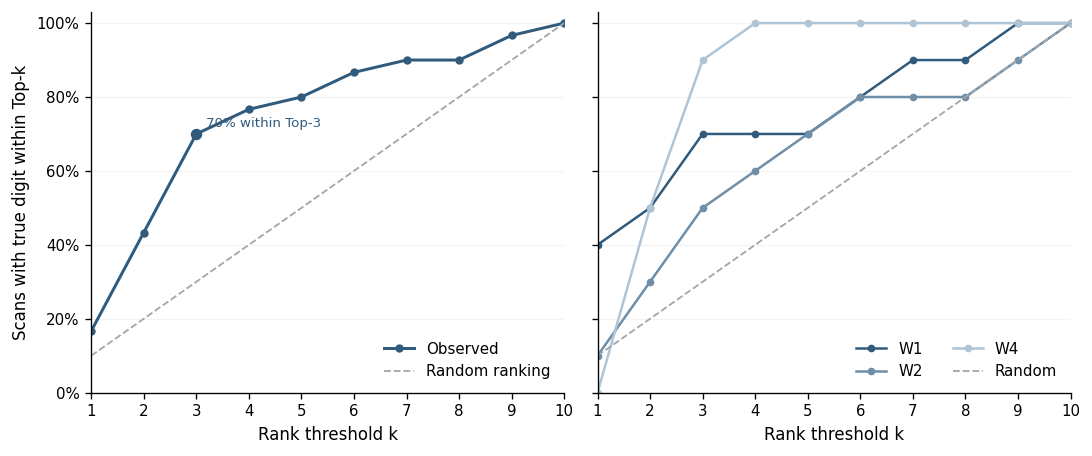

In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#A1A7AC"
DARK_GREY = "#596168"


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )


# Figure 1 — cumulative true-rank curve

def cumulative_topk(frame):
    ranks = frame["true_rank"].to_numpy(dtype=float)
    ks = np.arange(1, 11)

    values = np.array([
        np.mean(ranks <= k)
        for k in ks
    ])

    return ks, values


fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.9),
    sharey=True,
)

# Overall
ks, values = cumulative_topk(
    rq1_predictions
)

axes[0].plot(
    ks,
    100 * values,
    marker="o",
    markersize=4,
    linewidth=1.8,
    color=DARK_BLUE,
    label="Observed",
)

axes[0].plot(
    ks,
    10 * ks,
    linestyle="--",
    linewidth=1.1,
    color=MID_GREY,
    label="Random ranking",
)

axes[0].scatter(
    [3],
    [100 * values[2]],
    s=34,
    color=DARK_BLUE,
    zorder=4,
)

axes[0].text(
    3.18,
    100 * values[2] + 1.8,
    f"{100 * values[2]:.0f}% within Top-3",
    fontsize=8,
    color=DARK_BLUE,
)

axes[0].set_xlabel("Rank threshold k")
axes[0].set_ylabel(
    "Scans with true digit within Top-k"
)
axes[0].set_xlim(1, 10)
axes[0].set_ylim(0, 103)
axes[0].set_xticks(
    np.arange(1, 11)
)
axes[0].set_yticks(
    np.arange(0, 101, 20)
)
axes[0].set_yticklabels([
    f"{v}%"
    for v in np.arange(0, 101, 20)
])
axes[0].grid(
    axis="y",
    alpha=0.13,
)
axes[0].legend(
    frameon=False,
    loc="lower right",
)

# Per wheel
for wheel, color, label in [
    (1, DARK_BLUE, "W1"),
    (2, MID_BLUE, "W2"),
    (4, LIGHT_BLUE, "W4"),
]:
    ks, values = cumulative_topk(
        rq1_predictions[
            rq1_predictions["wheel"] == wheel
        ]
    )

    axes[1].plot(
        ks,
        100 * values,
        marker="o",
        markersize=3.6,
        linewidth=1.5,
        color=color,
        label=label,
    )

axes[1].plot(
    ks,
    10 * ks,
    linestyle="--",
    linewidth=1.1,
    color=MID_GREY,
    label="Random",
)

axes[1].set_xlabel("Rank threshold k")
axes[1].set_xlim(1, 10)
axes[1].set_ylim(0, 103)
axes[1].set_xticks(
    np.arange(1, 11)
)
axes[1].grid(
    axis="y",
    alpha=0.13,
)
axes[1].legend(
    frameon=False,
    ncol=2,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ1_Fig1_cumulative_rank",
)

plt.show()

curve_rows = []

for scope, frame in [
    ("Overall", rq1_predictions),
    ("W1", rq1_predictions[rq1_predictions["wheel"] == 1]),
    ("W2", rq1_predictions[rq1_predictions["wheel"] == 2]),
    ("W4", rq1_predictions[rq1_predictions["wheel"] == 4]),
]:
    ks, values = cumulative_topk(frame)

    for k, value in zip(ks, values):
        curve_rows.append({
            "scope": scope,
            "k": int(k),
            "topk_rate": float(value),
        })

pd.DataFrame(
    curve_rows
).to_csv(
    RESULT_DIR / "RQ1_cumulative_rank_curve.csv",
    index=False,
)

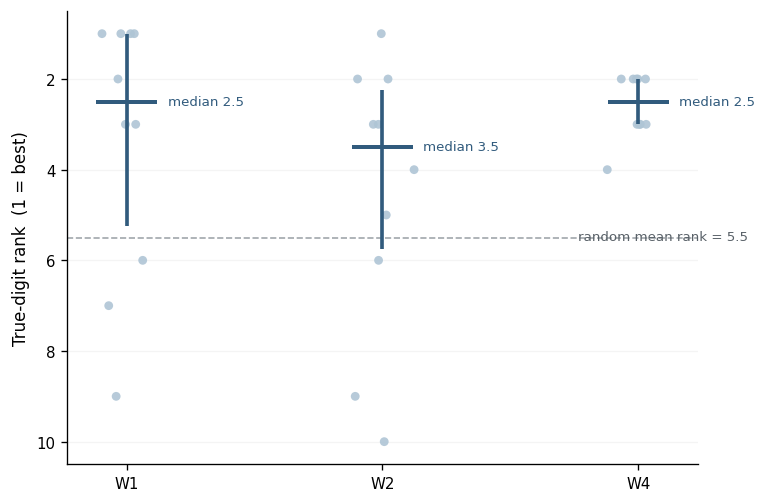

In [9]:
# Figure 2 — raw true-rank distribution

fig, ax = plt.subplots(
    figsize=(6.5, 4.3)
)

rng = np.random.default_rng(
    20260819
)

for i, wheel in enumerate(
    [1, 2, 4],
    start=1,
):
    values = rq1_predictions.loc[
        rq1_predictions["wheel"] == wheel,
        "true_rank",
    ].to_numpy(dtype=float)

    x = rng.normal(
        i,
        0.055,
        size=len(values),
    )

    ax.scatter(
        x,
        values,
        s=28,
        color=LIGHT_BLUE,
        edgecolor="none",
        alpha=0.9,
        zorder=2,
    )

    q1, median, q3 = np.quantile(
        values,
        [0.25, 0.5, 0.75],
    )

    ax.vlines(
        i,
        q1,
        q3,
        color=DARK_BLUE,
        linewidth=2.2,
        zorder=3,
    )

    ax.hlines(
        median,
        i - 0.12,
        i + 0.12,
        color=DARK_BLUE,
        linewidth=2.4,
        zorder=4,
    )

    ax.text(
        i + 0.16,
        median,
        f"median {median:.1f}",
        va="center",
        fontsize=8,
        color=DARK_BLUE,
    )

ax.axhline(
    5.5,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    3.43,
    5.62,
    "random mean rank = 5.5",
    ha="right",
    va="bottom",
    fontsize=8,
    color=DARK_GREY,
)

ax.set_xticks(
    [1, 2, 3]
)

ax.set_xticklabels(
    ["W1", "W2", "W4"]
)

ax.set_ylabel(
    "True-digit rank  (1 = best)"
)

ax.set_ylim(
    10.5,
    0.5,
)

ax.grid(
    axis="y",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ1_Fig2_true_rank_distribution",
)

plt.show()

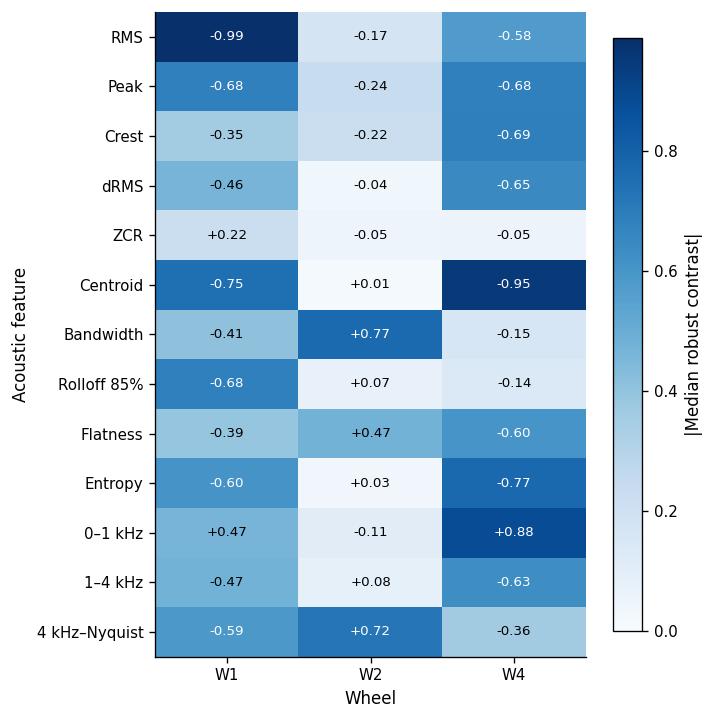

In [10]:
# Figure 3 — feature-level within-scan acoustic contrast

feature_label_map = {
    "rms": "RMS",
    "peak": "Peak",
    "crest": "Crest",
    "derivative_rms": "dRMS",
    "zcr": "ZCR",
    "spectral_centroid_hz": "Centroid",
    "spectral_bandwidth_hz": "Bandwidth",
    "rolloff85_hz": "Rolloff 85%",
    "spectral_flatness": "Flatness",
    "spectral_entropy": "Entropy",
    "band_0_1k": "0–1 kHz",
    "band_1_4k": "1–4 kHz",
    "band_4_nyquist": "4 kHz–Nyquist",
}

heatmap_data = (
    rq1_stats
    .pivot(
        index="feature",
        columns="wheel",
        values="median_contrast",
    )
    .reindex(BASE_FEATURES)
)

heatmap_data.columns = [
    f"W{int(w)}"
    for w in heatmap_data.columns
]

signed_values = heatmap_data.to_numpy(
    dtype=float
)

magnitude = np.abs(
    signed_values
)

fig, ax = plt.subplots(
    figsize=(6.0, 6.1)
)

image = ax.imshow(
    magnitude,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=np.nanmax(magnitude),
)

ax.set_xticks(
    np.arange(
        len(heatmap_data.columns)
    )
)

ax.set_xticklabels(
    heatmap_data.columns
)

ax.set_yticks(
    np.arange(
        len(BASE_FEATURES)
    )
)

ax.set_yticklabels([
    feature_label_map[name]
    for name in BASE_FEATURES
])

ax.set_xlabel("Wheel")
ax.set_ylabel("Acoustic feature")

threshold = (
    0.58
    * np.nanmax(magnitude)
)

for i in range(
    signed_values.shape[0]
):
    for j in range(
        signed_values.shape[1]
    ):
        ax.text(
            j,
            i,
            f"{signed_values[i, j]:+.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if magnitude[i, j] >= threshold
                else "black"
            ),
        )

cbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.92,
)

cbar.set_label(
    "|Median robust contrast|"
)

fig.tight_layout()

save_figure(
    fig,
    "RQ1_Fig3_feature_contrast_heatmap",
)

plt.show()

In [11]:
# Temporal-envelope values are retained as a supporting result.
# They remain available in RQ1_temporal_contrast.csv, but are not used
# as a main report figure for RQ1.

display(
    temporal_df.groupby("wheel")[
        "relative_db"
    ].agg(
        ["mean", "median", "std"]
    ).round(3)
)

,mean,median,std
wheel,,,
1,-0.858,-0.620,6.218
2,0.173,0.099,6.105
4,-0.390,-0.082,6.570


,Wheel,N scans,Top-1 (95% CI),Top-2 (95% CI),Top-3 (95% CI),Mean true rank,MRR
0,W1,10,"40.0% [16.8, 68.7]","50.0% [23.7, 76.3]","70.0% [39.7, 89.2]",3.40,0.559
1,W2,10,"10.0% [1.8, 40.4]","30.0% [10.8, 60.3]","50.0% [23.7, 76.3]",4.50,0.349
2,W4,10,"0.0% [0.0, 27.8]","50.0% [23.7, 76.3]","90.0% [59.6, 98.2]",2.60,0.408
3,Overall,30,"16.7% [7.3, 33.6]","43.3% [27.4, 60.8]","70.0% [52.1, 83.3]",3.50,0.439


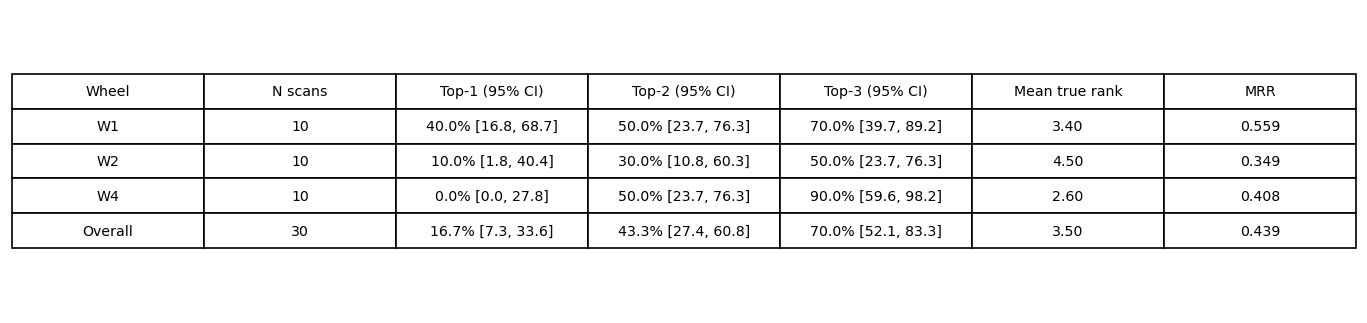

In [12]:
def pct_ci(row, k):
    return (
        f"{100 * row[f'top{k}']:.1f}% "
        f"[{100 * row[f'top{k}_ci_low']:.1f}, "
        f"{100 * row[f'top{k}_ci_high']:.1f}]"
    )


paper_ranking_table = pd.DataFrame({
    "Wheel": rq1_ranking_summary["scope"],
    "N scans": rq1_ranking_summary["n_scans"],
    "Top-1 (95% CI)": [
        pct_ci(row, 1)
        for _, row in rq1_ranking_summary.iterrows()
    ],
    "Top-2 (95% CI)": [
        pct_ci(row, 2)
        for _, row in rq1_ranking_summary.iterrows()
    ],
    "Top-3 (95% CI)": [
        pct_ci(row, 3)
        for _, row in rq1_ranking_summary.iterrows()
    ],
    "Mean true rank": rq1_ranking_summary["mean_true_rank"].map(
        lambda x: f"{x:.2f}"
    ),
    "MRR": rq1_ranking_summary["mrr"].map(
        lambda x: f"{x:.3f}"
    ),
})

paper_ranking_table.to_csv(
    RESULT_DIR / "RQ1_Table1_ranking_summary.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ1_Table1_ranking_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        paper_ranking_table.to_latex(
            index=False,
            escape=True,
        )
    )

display(paper_ranking_table)

fig, ax = plt.subplots(figsize=(11.5, 2.8))
ax.axis("off")

table = ax.table(
    cellText=paper_ranking_table.values,
    colLabels=paper_ranking_table.columns,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.5)

fig.tight_layout()

save_figure(
    fig,
    "RQ1_Table1_ranking_summary",
)

plt.show()

,Wheel,Feature,Median contrast,IQR,Sign consistency,Holm p
0,W1,rms,-0.99,"[-1.51, -0.25]",90%,0.355
5,W1,spectral centroid hz,-0.75,"[-0.83, -0.43]",90%,0.840
1,W1,peak,-0.68,"[-1.01, 0.14]",60%,1.000
19,W2,spectral bandwidth hz,0.77,"[0.24, 1.58]",90%,0.178
25,W2,band 4 nyquist,0.72,"[0.28, 1.68]",80%,1.000
21,W2,spectral flatness,0.47,"[-0.08, 1.93]",60%,1.000
31,W4,spectral centroid hz,-0.95,"[-1.49, 0.45]",60%,1.000
36,W4,band 0 1k,0.88,"[0.11, 2.08]",80%,0.254
35,W4,spectral entropy,-0.77,"[-2.09, 0.38]",60%,1.000


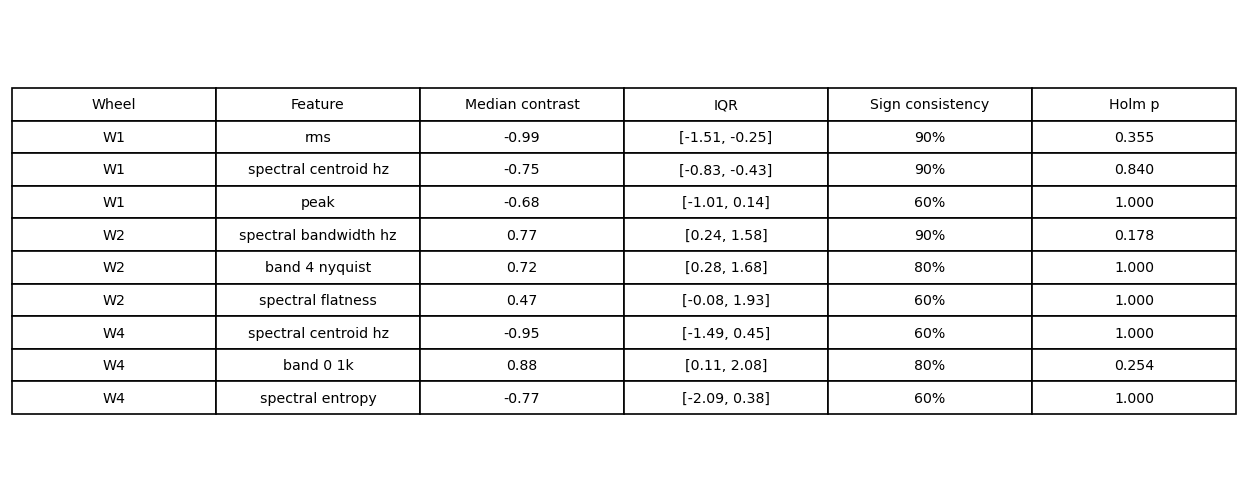

In [13]:
def format_p(value):
    if value < 0.001:
        return "<0.001"
    return f"{value:.3f}"


paper_feature_table = top_features[
    [
        "wheel",
        "feature",
        "median_contrast",
        "q1_contrast",
        "q3_contrast",
        "sign_consistency",
        "p_holm",
    ]
].copy()

paper_feature_table["wheel"] = paper_feature_table["wheel"].map(
    lambda w: f"W{w}"
)

paper_feature_table["feature"] = (
    paper_feature_table["feature"]
    .str.replace("_", " ", regex=False)
)

paper_feature_table["Median contrast"] = (
    paper_feature_table["median_contrast"]
    .map(lambda x: f"{x:.2f}")
)

paper_feature_table["IQR"] = [
    f"[{q1:.2f}, {q3:.2f}]"
    for q1, q3 in zip(
        paper_feature_table["q1_contrast"],
        paper_feature_table["q3_contrast"],
    )
]

paper_feature_table["Sign consistency"] = (
    100 * paper_feature_table["sign_consistency"]
).map(lambda x: f"{x:.0f}%")

paper_feature_table["Holm p"] = (
    paper_feature_table["p_holm"]
    .map(format_p)
)

paper_feature_table = paper_feature_table[
    [
        "wheel",
        "feature",
        "Median contrast",
        "IQR",
        "Sign consistency",
        "Holm p",
    ]
].rename(
    columns={
        "wheel": "Wheel",
        "feature": "Feature",
    }
)

paper_feature_table.to_csv(
    RESULT_DIR / "RQ1_Table2_top_features.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ1_Table2_top_features.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        paper_feature_table.to_latex(
            index=False,
            escape=True,
        )
    )

display(paper_feature_table)

fig, ax = plt.subplots(figsize=(10.5, 4.3))
ax.axis("off")

table = ax.table(
    cellText=paper_feature_table.values,
    colLabels=paper_feature_table.columns,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.35)

fig.tight_layout()

save_figure(
    fig,
    "RQ1_Table2_top_features",
)

plt.show()

## 9. RQ1 result record

The final cell writes a short machine-readable conclusion. It is intentionally narrower than a thesis discussion: it records what this experiment supports, what it does not support, and why the next validity tests are still needed.

In [14]:
overall = rq1_ranking_summary[
    rq1_ranking_summary["scope"] == "Overall"
].iloc[0]

n_holm = int(
    (rq1_stats["p_holm"] < 0.05).sum()
)

conclusion = {
    "research_question": (
        "Is the movement ending at the known true-gate digit acoustically "
        "different from the other nine movements in the same scan?"
    ),
    "dataset": "RQ1-4 controlled acoustic validity dataset",
    "password": "3517",
    "condition_used": "LOADED",
    "direction": "CCW",
    "wheels": [1, 2, 4],
    "n_loaded_scans": int(loaded["scan_id"].nunique()),
    "n_loaded_movements": int(len(loaded)),
    "feature_tests_surviving_holm_0_05": n_holm,
    "overall_top1": float(overall["top1"]),
    "overall_top2": float(overall["top2"]),
    "overall_top3": float(overall["top3"]),
    "overall_mean_true_rank": float(overall["mean_true_rank"]),
    "overall_top1_p_gt_random": float(overall["top1_p_gt_chance"]),
    "overall_top2_p_gt_random": float(overall["top2_p_gt_chance"]),
    "overall_top3_p_gt_random": float(overall["top3_p_gt_chance"]),
    "interpretation": (
        "The loaded scans contain measurable, wheel-dependent acoustic structure. "
        "The simple current-movement model places the true digit within the top three "
        "more often than random ranking overall, but strict Top-1 performance is weak "
        "and no individual target feature survives Holm correction at 0.05. "
        "RQ1 therefore supports acoustic feasibility, not a stable universal true-gate classifier."
    ),
    "limitation": (
        "Only ten loaded scans are available per wheel and all scans use one password "
        "on one lock. The analysis is within-password and does not establish "
        "cross-password generalisation or isolate lock sound from drive-system sound."
    ),
    "decision": (
        "Continue to the controlled validity tests: RQ2 tests the effect of shackle loading "
        "and RQ3 tests whether the discriminative signal is attributable to the lock rather "
        "than motor/transmission acoustics."
    ),
}

with open(
    RESULT_DIR / "RQ1_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )

run_info = {
    "notebook": "01_RQ1_Acoustic_Feasibility.ipynb",
    "source_notebook": "01_RQ1_Acoustic_Feasibility.ipynb",
    "truth_source": "pre-specified experimental password 3517",
    "feature_cache": str(CACHE_PATH),
    "feature_count_cached": 29,
    "feature_count_used_for_ranking": 13,
    "ranking_validation": "leave-one-scan-out within each wheel",
    "classifier": {
        "type": "LogisticRegression",
        "C": 1.0,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": 0,
    },
    "multiple_testing": "Holm correction across 13 target features within each wheel",
    "note": "RQ1 feasibility experiment; not a MAIN model result.",
}

with open(
    RESULT_DIR / "RQ1_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(json.dumps(conclusion, indent=2))

print("\nSaved files:")
for path in sorted(RESULT_DIR.glob("RQ1_*")):
    print(" -", path.name)

{
  "research_question": "Is the movement ending at the known true-gate digit acoustically different from the other nine movements in the same scan?",
  "dataset": "RQ1-4 controlled acoustic validity dataset",
  "password": "3517",
  "condition_used": "LOADED",
  "direction": "CCW",
  "wheels": [
    1,
    2,
    4
  ],
  "n_loaded_scans": 30,
  "n_loaded_movements": 300,
  "feature_tests_surviving_holm_0_05": 0,
  "overall_top1": 0.16666666666666666,
  "overall_top2": 0.43333333333333335,
  "overall_top3": 0.7,
  "overall_mean_true_rank": 3.5,
  "overall_top1_p_gt_random": 0.17549487903389516,
  "overall_top2_p_gt_random": 0.0031110486319833814,
  "overall_top3_p_gt_random": 7.277835375242025e-06,
  "interpretation": "The loaded scans contain measurable, wheel-dependent acoustic structure. The simple current-movement model places the true digit within the top three more often than random ranking overall, but strict Top-1 performance is weak and no individual target feature survives H